<a href="https://colab.research.google.com/github/keshav123333/langgraph/blob/main/lecture_9_iterative_workflow/lecture_9_iterative_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install langchain-huggingFace langgraph


# yaha maine kayde se like optimizer ke liye and generate tweet ke liye and evealuation teeno ke iye alag llm use karna chaiye jo uss task m excel ho
# like research ki kaunsa llm  vocab achi usse tweet generate kaunsa ache se feedback leta kaunsa sa llm evealuation achi karta aise

In [ ]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

llm=HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",


    temperature=0.7
)


# yaha maine kayde se like optimizer ke liye and generate tweet ke liye and evealuation teeno ke iye alag llm use karna chaiye jo uss task m excel ho
# like research ki kaunsa llm  vocab achi usse tweet generate kaunsa ache se feedback leta kaunsa sa llm evealuation achi karta aise

model=ChatHuggingFace(llm=llm)
optimizer_llm=ChatHuggingFace(llm=llm)

## Structred model

In [ ]:
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser

In [ ]:
from typing import Literal
class TweetEvaluation(BaseModel):
  evaluation:Literal["approved","needs_improvement"]=Field(..., description="Final evaluation result.")
  feedback: str = Field(..., description="feedback for the tweet.")


In [ ]:
parser=PydanticOutputParser(pydantic_object=TweetEvaluation)


In [ ]:
template=PromptTemplate(
    template=" So now iam analysing a tweet please give output in specfic format {tweet} /n {format_instruction}",
    input_variables=["tweet"],
    partial_variables={"format_instruction":parser.get_format_instructions()}
)



In [ ]:
structured_model = template | model | parser

In [ ]:
structured_model.invoke({"tweet": "keshav rai army public school jaipur and manipal university jaipur, A 20 year old boy"})


TweetEvaluation(evaluation='needs_improvement', feedback='The tweet seems to be a simple statement of affiliation with two institutions. It does not contain any meaningful content or opinion. Therefore, it requires improvement to be a valid tweet.')

# workflow

In [ ]:
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal,Annotated
import operator

In [ ]:
# state
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved", "needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [ ]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state.get("topic")}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = model.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}




In [ ]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?
2. Humor – Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness – Is it short, sharp, and scroll-stopping?
4. Virality Potential – Would people retweet or share it?
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
""")
]

    response = structured_model.invoke({"tweet":messages})

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}


def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response =  optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [ ]:

def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

In [ ]:
graph=StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)


#connected

graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
# isme dekh yaha humne node condition ye ki if approved toh end pe chale ja if improvement chaoyetoh optimize func ko chala vapas

graph.add_conditional_edges('evaluate',route_evaluation,{"approved":END,"need_improvement":'optimize'})
graph.add_edge('optimize','evaluate')

workflow = graph.compile()


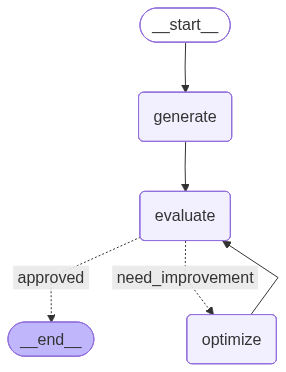

In [ ]:
workflow

In [ ]:
initial_state = {
    "topic": "keshav rai army public school jaipur and manipal university jaipur, A 20 year old boy",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [ ]:

result

{'topic': 'keshav rai army public school jaipur and manipal university jaipur, A 20 year old boy',
 'tweet': '"Just met a 20-year-old who\'s basically a Google search result come to life: \'Keshav Rai from Army Public School Jaipur, graduated from Manipal University Jaipur (obviously a genius)\'. I\'m shook, not by his achievements but by his Twitter bio length" #KeshavRaiArmy',
 'evaluation': 'approved',
 'feedback': "This tweet is fresh and original, using a clever observation to poke fun at the Twitter bio length. The humor is genuine and may not make everyone laugh, but it's clever enough to elicit a chuckle. The punchiness is good, and the tweet is short and to the point. Virality Potential is also good, as people may retweet or share it to share a laugh. The format is well-formed, and the tweet does not exceed 280 characters or read like a traditional setup-punchline joke.",
 'iteration': 1,
 'max_iteration': 5,
 'tweet_history': ['"Just met a 20-year-old who\'s basically a Googl